# Random numbers basics

**Table of contents**<a id='toc0_'></a>    
- 1. [Set up](#toc1_)    
- 2. [Random numbers](#toc2_)    
  - 2.1. [Numpy](#toc2_1_)    
  - 2.2. [Seeding Random Numbers in NumPy](#toc2_2_)    
  - 2.3. [Basic distributions](#toc2_3_)    
  - 2.4. [Analytical results](#toc2_4_)    
- 3. [Load and save variables](#toc3_)    
  - 3.1. [Pickle](#toc3_1_)    
  - 3.2. [Saving with numpy](#toc3_2_)    
- 4. [Dice cup class](#toc4_)    
- 5. [Applications](#toc5_)    
  - 5.1. [ AR(1) process](#toc5_1_)    
  - 5.2. [Monte Carlo as Numerical Expectation](#toc5_2_)    
- 6. [Summary](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## 1. <a id='toc1_'></a>[Set up](#toc0_)

You will learn how to use a random number generator with a seed and produce simulation results (**numpy.random**, **scipy.stats**), and calculate the expected value of a random variable through Monte Carlo integration. You will learn how to save your results for later use (**pickle**).

**Links:**

* [numpy.random](https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.random.html)
* [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html)
* datacamp on [pickle](https://www.datacamp.com/community/tutorials/pickle-python-tutorial)

**Imports:** We now import all the modules, we need for this notebook.

In [1]:
import pickle
import numpy as np

from scipy.stats import norm # normal distribution

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size': 14})

## 2. <a id='toc2_'></a>[Random numbers](#toc0_)

The two main approaches to generating random numbers are:

1. **Physical observations** of random processes (radioactive decay,  atmospheric noise, roulette wheels, etc.)
2. **Algorithms** creating **pseudo-random numbers**. Numbers that are *determined* by the algo but **appear** random.

**Pseudo-random numbers** satisfy properties such that they are as good as random. It should be impossible (for all practical purposes) to calculate, or otherwise guess, from any given subsequence, any previous or future values in the sequence.

**More information:** See this [video](https://www.youtube.com/watch?v=C82JyCmtKWg&app=desktop#fauxfullscreen) by Infinite Series.

### 2.1. <a id='toc2_1_'></a>[Numpy](#toc0_)

Numpy provides various functions for **drawing** random numbers. We can, for example, draw random integers between 0 and 10000:

In [2]:
X = np.random.randint(0,10000,size=5)
print(X) # the result is a 1D array of 5 random integers between 0 and 10000

[3309 5866 5074 5107 5076]


**Problem:** How can we reproduce our results the next time we open Python?

**Solution:** Use a **seed**. This will fix the algorithm to give the same set numbers each time.     
Choose the seed, and reset the random number generator:

### 2.2. <a id='toc2_2_'></a>[Seeding Random Numbers in NumPy](#toc0_)

There are **two common ways** to set seeds in NumPy:

1) Create a *local* random number generator  
   `rng = np.random.default_rng(seed)` and then draw with `rng.normal(...)`, `rng.random(...)`, etc.

2) Set the seed globally: the *module-level* seed  
   `np.random.seed(seed)` and then draw with `np.random.normal(...)`, `np.random.random(...)`, etc.

**Recommendation: use the modern local RNG**
- Create a local generator: `rng = np.random.default_rng(seed)`.
- Pass `rng` into functions (no hidden global state).
- Avoid global seeding (`np.random.seed(...)`) to keep simulations **reproducible** and **testable**.



In [3]:
# draw random integers between 0 and 10000 using default_rng
rng = np.random.default_rng(42)
print('Five uniforms                 :', rng.random(5))

rng2 = np.random.default_rng(42)
print('Five uniforms (same seed)     :', rng2.random(5))

rng2 = np.random.default_rng(7)
print('Five uniforms (different seed):', rng2.random(5))

Five uniforms                 : [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
Five uniforms (same seed)     : [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
Five uniforms (different seed): [0.62509547 0.8972138  0.77568569 0.22520719 0.30016628]


In [4]:
# Draw random numbers using the (older) global state
# NOTE: shown for contrast only -- prefer the local default_rng approach above

print('set seed to 2000 and create numbers:')
np.random.seed(2000)
print(np.random.uniform(size=5))

print('reset algorithm by stating the same seed again:')
np.random.seed(2000)
print(np.random.uniform(size=5))

set seed to 2000 and create numbers:
[0.57051729 0.56452876 0.48844183 0.33647775 0.37586818]
reset algorithm by stating the same seed again:
[0.57051729 0.56452876 0.48844183 0.33647775 0.37586818]


In [5]:
# a. same seed, same draws (baseline)
np.random.seed(2024)
a1 = np.random.normal(size=5)

# b. re-seed with the SAME seed, but do an unrelated draw in between
np.random.seed(2024)
_ = np.random.random(size=10_000)   # unrelated code changes the GLOBAL stream
a2 = np.random.normal(size=5)

print('Global: same seed, no interference           ->', a1)
print('Global: same seed, but unrelated draw before ->', a2)
print('Equal?', np.allclose(a1, a2))  # False

Global: same seed, no interference           -> [ 1.66804732  0.73734773 -0.20153776 -0.15091195  0.91605181]
Global: same seed, but unrelated draw before -> [-0.04178604 -1.89283277 -0.34142387 -0.75696399 -0.01234819]
Equal? False


In [6]:
# a. same seed, same local stream
rng1 = np.random.default_rng(2024)
b1 = rng1.normal(size=5)

# b. unrelated draws use a DIFFERENT generator -> does not affect our stream
rng_other = np.random.default_rng(123)
_ = rng_other.random(size=10_000)

# c. recreate the SAME local stream with the SAME seed
rng2 = np.random.default_rng(2024)
b2 = rng2.normal(size=5)

print('Local: seed=2024       ->', b1)
print('Local: seed=2024 again ->', b2)
print('Equal?', np.allclose(b1, b2))  # True

Local: seed=2024       -> [ 1.02885687  1.64192004  1.14671953 -0.97317952 -1.3928001 ]
Local: seed=2024 again -> [ 1.02885687  1.64192004  1.14671953 -0.97317952 -1.3928001 ]
Equal? True


**Global vs. Local RNG** 

- **Global:** `np.random.seed(SEED)` + `np.random.*`
  - One **shared stream** for your whole session.
  - Any **unrelated draw** (even in another cell/library) **changes** the stream → same seed can yield **different results** depending on what ran before.

- **Local (recommended):** `rng = np.random.default_rng(SEED)` then `rng.*`
  - Each `rng` has its **own independent stream**.
  - Same seed returns the same sequence; other generators **don’t interfere**.
  - Easy to **pass into functions** for reproducible simulations.

**Takeaway:** Prefer the **local generator** (`default_rng`) to avoid hidden global state and keep results reproducible.


### State of generator

We can get and reset the random number generator:

In [7]:
rng = np.random.default_rng(2024)
state = rng.bit_generator.state # save the state of the generator
print(rng.normal(size=5))  # draw 5 numbers
print(rng.normal(size=5))  # draw 5 numbers
rng.bit_generator.state = state  # reset the generator to the saved state
print(rng.normal(size=5))  # draw 5 numbers again; should be the same as the first draw

[ 1.02885687  1.64192004  1.14671953 -0.97317952 -1.3928001 ]
[0.06719636 0.86135092 0.5091868  1.81028557 0.75084347]
[ 1.02885687  1.64192004  1.14671953 -0.97317952 -1.3928001 ]


### Multiple generators

We can spawn multiple generators from one generator.

In [8]:
# a. same seed, same draws (baseline)
rng = np.random.default_rng(2024)
rng1,rng2 = rng.spawn(2)

print('rng1 normal draws:', rng1.normal(size=5))
print('rng2 normal draws:', rng2.normal(size=5))

print('')

# b. unrelated draws use a DIFFERENT generator -> does not affect our stream
rng = np.random.default_rng(2024)
rng1,rng2 = rng.spawn(2)

print('rng1 normal draws:', rng1.normal(size=5))
print('rng1 normal draws:', rng1.normal(size=5))
print('rng2 normal draws:', rng2.normal(size=5))

rng1 normal draws: [-0.21172434 -0.17161223  0.59818654 -0.60552217 -0.17606067]
rng2 normal draws: [ 2.21401612 -0.8298834   1.05920099  0.41491568 -0.40150884]

rng1 normal draws: [-0.21172434 -0.17161223  0.59818654 -0.60552217 -0.17606067]
rng1 normal draws: [-0.31857056 -0.39627191 -0.94246538  1.03239686  0.72810779]
rng2 normal draws: [ 2.21401612 -0.8298834   1.05920099  0.41491568 -0.40150884]


### 2.3. <a id='toc2_3_'></a>[Basic distributions](#toc0_)

Draw random numbers from various distributions: normal, beta, uniform.

In [9]:
rng = np.random.default_rng(123)  # local, reproducible stream
X = rng.normal(0, 1, 10**6) # 1 million draws from a normal distribution
Y = rng.beta(5, 2, 10**6)   # 1 million draws from a beta distribution
Z = rng.uniform(-2, 2, 10**6)   # 1 million draws from a uniform distribution

Plot the various distributions:

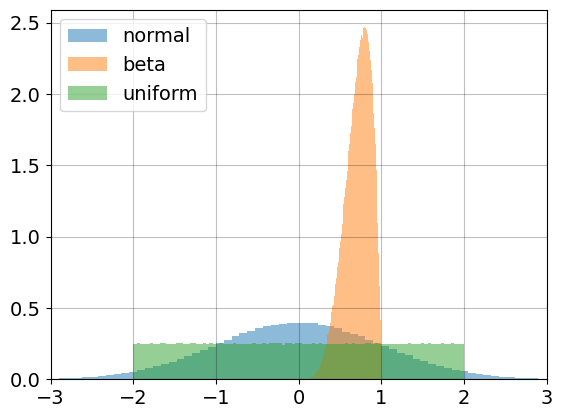

In [10]:
fig = plt.figure(dpi=100)
ax = fig.add_subplot(1,1,1)
ax.hist(X,bins=100,density=True,alpha=0.5,label='normal') # alpha < 1 = transparent
ax.hist(Y,bins=100,density=True,alpha=0.5,label='beta')
ax.hist(Z,bins=100,density=True,alpha=0.5,label='uniform')
#ax.hist(K,bins=100,density=True,alpha=0.5,label='choice')

ax.set_xlim([-3,3])
ax.legend(loc='upper left');

**Task:** Follow this [link](https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.random.html). Choose a distribution and add it to the figure above.

### 2.4. <a id='toc2_4_'></a>[Analytical results](#toc0_)

Sometimes, you want to compare a distribution of numbers to a **known** distribution.   

For instance, how close are our draws to a normal distribution?  

In this case, the `scipy.stats.norm` module comes in handy.  

It operates differently from numpy. It creates an **object** to generate numbers from rather than just making an array at once. 

F pdf at 0.0: 0.503
F cdf at 0.0: 0.369


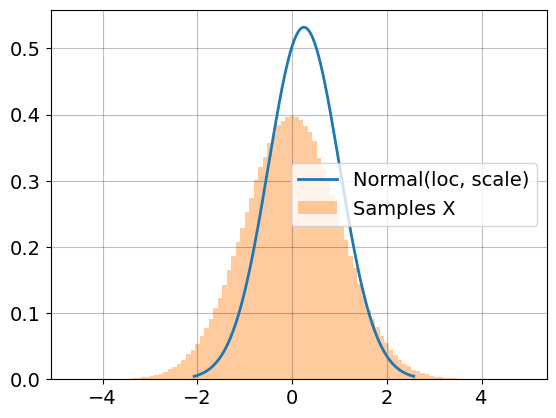

In [11]:
from scipy.stats import norm # we import the normal distribution from scipy.stats

# local RNG for reproducible draws
rng = np.random.default_rng(123)

# a) create analytical (frozen) Normal distribution
loc_guess, scale_guess = 0.25, 0.75
# loc_guess, scale_guess = 0.0, 1.0

F = norm(loc=loc_guess, scale=scale_guess)

# example: 50 random draws using the local RNG
rnd = F.rvs(size=50, random_state=rng)

# print pdf and cdf at 0.0
print(f'F pdf at 0.0: {F.pdf(0.0):.3f}\nF cdf at 0.0: {F.cdf(0.0):.3f}')

# b) vector of x values over central support (use percent point function)
x_low, x_high = F.ppf([0.001, 0.999])
x_support = np.linspace(x_low, x_high, 5000) # makes a fine grid between x_low and x_high
pdf_vals = F.pdf(x_support) # pdf values at each point in x_support

# c) compare empirical X (from before) with fitted/guessed Normal
fig, ax = plt.subplots(dpi=100)
ax.plot(x_support, pdf_vals, lw=2, label='Normal(loc, scale)')
ax.hist(X, bins=100, density=True, alpha=0.4, label='Samples X')
ax.legend();

**Task:** Make the pdf fit the histogram closely.

## 3. <a id='toc3_'></a>[Load and save variables](#toc0_)

### 3.1. <a id='toc3_1_'></a>[Pickle](#toc0_)

A good allround method for loading and saving is to use **pickle**. Here is how to save:

In [12]:
# a. variables
my_dict = {'a': 1, 'b': 2}      # create a standard Python dictionary with two key–value pairs
my_vec = np.array([1, 2, 3])    # create a NumPy array (vector) with three integers
my_tuple = (1, 4, 2)           # create a Python tuple (immutable sequence)

# b. put them in a dictionary
my_data = {}                              # start an empty dictionary to collect all objects
my_data['my_dict'] = my_dict              # store the dict under the key 'my_dict'
my_data['my_vec'] = my_vec                # store the NumPy array under the key 'my_vec'
my_data['my_tuple'] = my_tuple          # store the tuple under the key 'my_tuple'

# c. save the dictionary in a file
# 'with' ensures the file is properly closed even if an error occurs inside the block
# open(..., 'wb') opens (or creates) a file named 'data.p' in write-binary mode (required by pickle)
with open('data.p', 'wb') as f:           # f gives a name to the object created by with statement.
    pickle.dump(my_data, f)               # serialize (pickle) the 'my_data' dictionary into the file

Delete the variables:

In [13]:
del my_dict
del my_vec
del my_tuple

Load the data again:

In [14]:
# a. try
try:
    print(my_tuple)
except:
    print('my_vec does not exist')
    
# b. load    
with open(f'data.p', 'rb') as f: # rb = read binary
    data = pickle.load(f)

# Unpack data
my_dict = data['my_dict']
my_vec = data['my_vec']
my_tuple = data['my_tuple']

# c. try again
print(my_vec)
print(my_tuple)

my_vec does not exist
[1 2 3]
(1, 4, 2)


### 3.2. <a id='toc3_2_'></a>[Saving with numpy](#toc0_)

When only saving/loading **numpy arrays**, an alternative is to use ``np.savez`` (or ``np.savez_compressed``). This is typically faster than pickle.

Here is how to save some data:

In [15]:
my_data = {}
my_data['A'] = np.array([1,2,3])
my_data['B'] = np.zeros((5,8))
my_data['C'] = np.ones((7,3,8))
np.savez(f'data.npz', **my_data)
# '**' unpacks the dictionary

Here is how to load the data again:

In [16]:
# a. delete
del my_data

# a. load all
my_data = {}
with np.load(f'data.npz') as data_obj:
    for key in data_obj.files:
        my_data[key] = data_obj[key]
print(my_data['A'])

# b. load single array
X = np.load(f'data.npz')['A']
print(X)

[1 2 3]
[1 2 3]


## 4. <a id='toc4_'></a>[Dice cup class](#toc0_)

In [17]:
class dice_cup:  # define a class named 'dice_cup'
    
    def __init__(self, ndice, rng=None):
        self.ndice = ndice
        self.rng = np.random.default_rng() if rng is None else rng
        self.dice = None

    def roll(self):
        self.dice = self.rng.integers(1, 7, size=self.ndice) # roll ndice dice (values 1 to 6)
        print(self.dice)

    def shuffle(self):
        self.rng.shuffle(self.dice)
        print(self.dice)
    
    def roll_and_sum(self):            # method placeholder: supposed to roll and return the total
        pass                           # 'pass' = do nothing (no roll, no sum, no print)
        
# usage example
my_dice_cup = dice_cup(4)   # create a dice_cup that holds 4 dice
my_dice_cup.roll()          # roll the 4 dice; prints something like [2 6 1 4]
my_dice_cup.shuffle()       # shuffle their order; prints a permuted array (e.g., [6 4 2 1])
my_dice_cup.roll_and_sum()  # currently does nothing because the method contains only 'pass'

[1 5 6 4]
[6 4 5 1]


**Task:** Add a method ``roll_and_sum()`` to the class above, which rolls and prints the sum of the dice.

*(You can delete the pass statement when starting to code. It's there to inform Python that roll_and_sum() is well defined as Python cannot handle a totally codeless function)*

In [18]:
## Answer

class dice_cup:  # define a class named 'dice_cup'
    
    def __init__(self, ndice, rng=None):
        self.ndice = ndice
        self.rng = np.random.default_rng() if rng is None else rng
        self.dice = None

    def roll(self):
        self.dice = self.rng.integers(1, 7, size=self.ndice)
        print(self.dice)

    def shuffle(self):
        self.rng.shuffle(self.dice)
        print(self.dice)
        
    def roll_and_sum(self):
        self.roll()                # roll the dice
        print(np.sum(self.dice))    # print the sum of the dice
        
my_dice_cup = dice_cup(4)
my_dice_cup.roll_and_sum()

[4 6 1 1]
12


## 5. <a id='toc5_'></a>[Applications](#toc0_)

### 5.1. <a id='toc5_1_'></a>[ AR(1) process](#toc0_)

AR(1) is an Autoregressive Process with 1 lag:

$$
y_t=\rho\,y_{t-1}+\varepsilon_t,\qquad \varepsilon_t\sim\mathcal N(0,\sigma^2),\; |\rho|<1
$$

Key properties (stationary case):
- $\mathbb E[y_t]=0$, 
- $\operatorname{Var}(y_t)=\sigma^2/(1-\rho^2)$,

In [19]:
# a. function to simulate an AR(1) process
def sim_AR1(rng,T=5000, rho=0.9, sigma=0.1):

    eps = rng.normal(0, sigma, size=T) # generate a time series of shocks (epsilon)

    y = np.empty(T)
    y[0] = 0.0 # initialize y
    for t in range(1, T): # iterate from t=1 to T-1
        y[t] = rho*y[t-1] + eps[t] # update y according to AR(1) formula

    return y # returns the simulated series

# b. simulate an AR(1) process
rng = np.random.default_rng(3)
T = 1_000
rho = 0.95
sigma = 0.1
y = sim_AR1(rng=rng, T=T, rho=rho, sigma=sigma)

# c. compute empirical mean and variance, and compare with theoretical values
burn_in = 100 # discard the first observations to reduce the effect of initial conditions
print(f'{y[burn_in:].mean() = :.4f} [theoretical: {0.0:.4f}]')
print(f'{y[burn_in:].var()  = :.4f} [theoretical: {(sigma**2)/(1-rho**2):.4f}]')

y[burn_in:].mean() = 0.0926 [theoretical: 0.0000]
y[burn_in:].var()  = 0.0977 [theoretical: 0.1026]


Time-series plot:

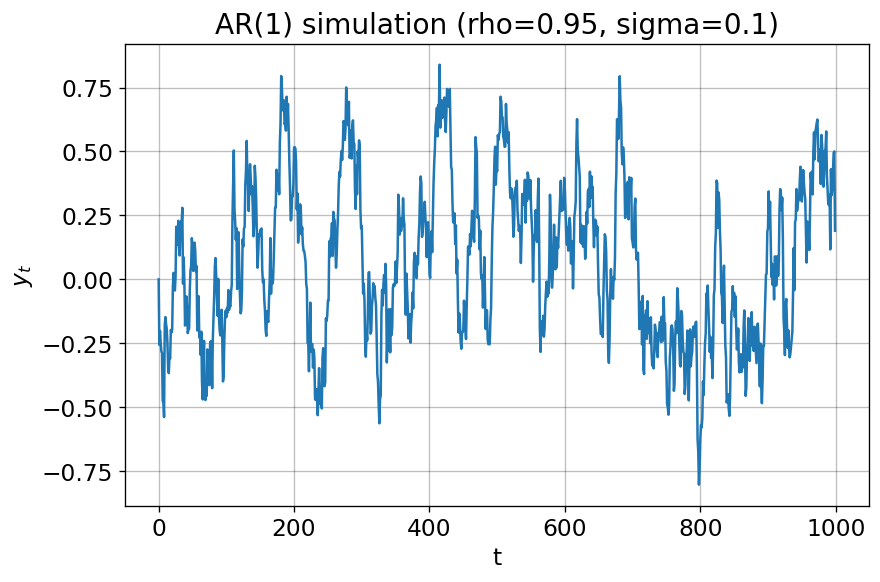

In [20]:
fig, ax = plt.subplots(figsize=(8,5), dpi=120)
ax.plot(y)
ax.set_title('AR(1) simulation (rho=0.95, sigma=0.1)')
ax.set_xlabel('t')
ax.set_ylabel('$y_t$');

seed=3 run equals seed=3 repeat: True


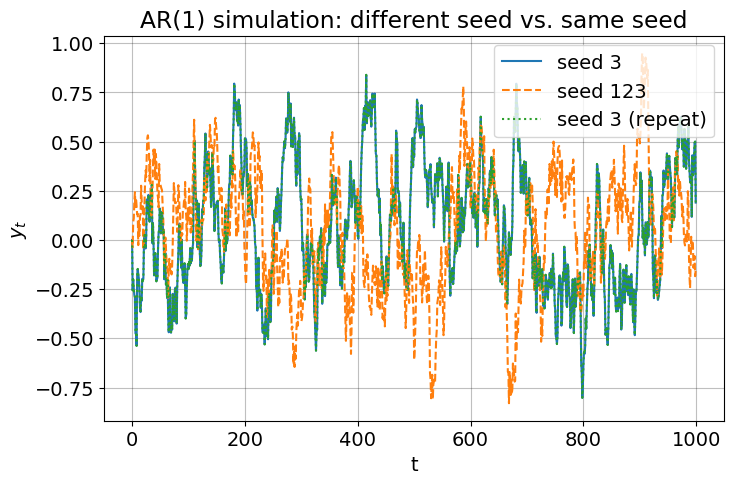

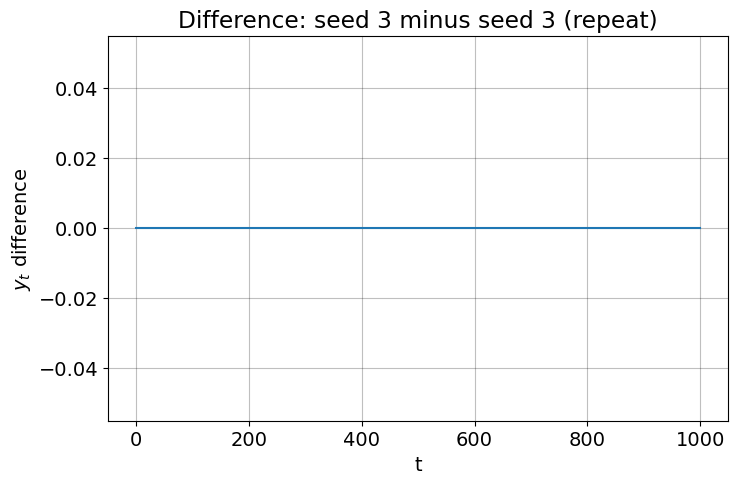

In [21]:
# a. simulate with three seeds: 3, 123, and 3 again
T, rho, sigma = 1000, 0.95, 0.1

rng = np.random.default_rng(3)
y_seed3 = sim_AR1(rng=rng, T=T, rho=rho, sigma=sigma)

rng = np.random.default_rng(123)
y_seed123 = sim_AR1(rng=rng, T=T, rho=rho, sigma=sigma)

rng = np.random.default_rng(3)
y_seed3_repeat = sim_AR1(rng=rng, T=T, rho=rho, sigma=sigma)

# verify overlay: same seed => identical path
print('seed=3 run equals seed=3 repeat:', np.allclose(y_seed3, y_seed3_repeat))

# b. overlay plot
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(y_seed3, label='seed 3')
ax.plot(y_seed123, label='seed 123', linestyle='--')
ax.plot(y_seed3_repeat, label='seed 3 (repeat)', linestyle=':')
ax.set_title('AR(1) simulation: different seed vs. same seed')
ax.set_xlabel('t')
ax.set_ylabel('$y_t$')
ax.legend();

# c. show the difference is zero everywhere
fig2, ax2 = plt.subplots(figsize=(8,5))
ax2.plot(y_seed3 - y_seed3_repeat)
ax2.set_title('Difference: seed 3 minus seed 3 (repeat)')
ax2.set_xlabel('t')
ax2.set_ylabel('$y_t$ difference');

### 5.2. <a id='toc5_2_'></a>[Monte Carlo as Numerical Expectation](#toc0_)

**Goal.** Estimate $\mathbb{E}[g(X)]$ — the expected value of some function $g$ applied to a random variable $X$ — when a closed-form answer is unavailable.

**Idea.** Draw $N$ independent and identically distributed (i.i.d.) samples $X_1,\dots,X_N$ from the distribution of $X$ and compute the sample average:
$$
\hat{\theta} = \frac{1}{N}\sum_{i=1}^N g(X_i) \;\xrightarrow{\;N\to\infty\;}\; \mathbb{E}[g(X)].
$$
This follows from the **Law of Large Numbers**.

**Example:** Use for the mean $g(X) = X$.

In [22]:
# a. Monte Carlo estimate of E[X] for X ~ Normal(mu, sigma^2)
rng   = np.random.default_rng(1)  # create RNG; seeding (1) makes results reproducible
mu    = 2.0                       # true mean of the Normal distribution
sigma = 3.0                       # true standard deviation 
N     = 1000                      # number of simulated draws -> vary N to see how the estimate stabilizes

# b. draw N i.i.d. samples from N(mu, sigma^2)
x = rng.normal(loc=mu, scale=sigma, size=N)

# c. Monte Carlo estimator: sample mean approximates E[X]
theta_hat = x.mean()

# d. print output
print(f'MC estimate of E[X]: {theta_hat:.3f}  (true μ = {mu})')

MC estimate of E[X]: 1.837  (true μ = 2.0)


Compare small N vs large N:

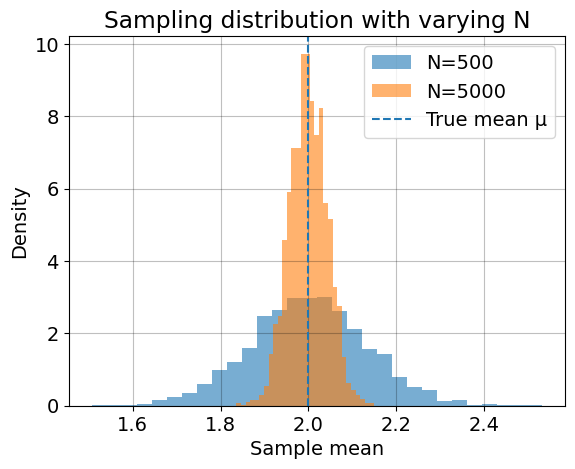

In [23]:
# a. compute
rng   = np.random.default_rng(3)
mu, sigma = 2.0, 3.0
R = 3000
N_small, N_large = 500, 5000

means_small = rng.normal(mu, sigma, size=(R, N_small)).mean(axis=1)
means_large = rng.normal(mu, sigma, size=(R, N_large)).mean(axis=1)

# b. plot
fig, ax = plt.subplots()
ax.hist(means_small, bins=30, density=True, alpha=0.6, label=f'N={N_small}')
ax.hist(means_large, bins=30, density=True, alpha=0.6, label=f'N={N_large}')
ax.axvline(mu, linestyle='--', label='True mean μ')
ax.set_xlabel('Sample mean')
ax.set_ylabel('Density')
ax.set_title('Sampling distribution with varying N')
ax.legend();

Plot standard deviation of mean estimates across different runs:

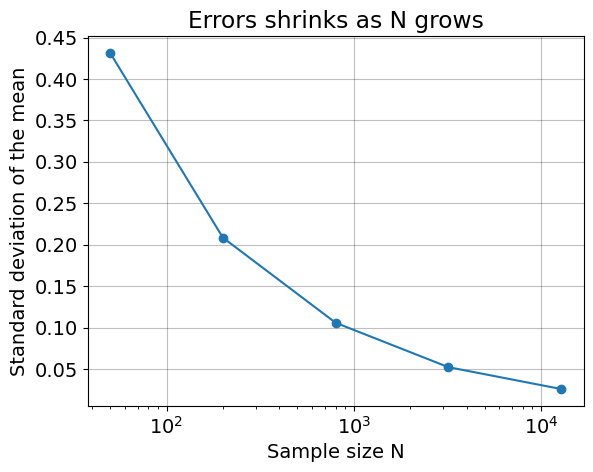

In [24]:
# a. settings
rng   = np.random.default_rng(2)
mu, sigma = 2.0, 3.0
Ns = np.array([50*(4**k) for k in range(5)])  # sample sizes: 50, 2500, 125000, 6250000
R  = 1000

# b. compute
empirical_se = []
for N in Ns:
    means = rng.normal(mu, sigma, size=(R, N)).mean(axis=1)  # R sample means
    empirical_se.append(np.std(means, ddof=1))               # SD of means = SE

empirical_se = np.array(empirical_se)

# c. plot
fig, ax = plt.subplots()
ax.plot(Ns, empirical_se, marker='o')
ax.set_xscale('log')
ax.set_xlabel('Sample size N')
ax.set_ylabel('Standard deviation of the mean')
ax.set_title('Errors shrinks as N grows');

***What does $R$ do?***

- Think of $R$ as **rerunning the same experiment** $R$ times with fresh random draws each time.  
- Each run gives one estimate $\hat{\theta}$. After $R$ runs you have $\hat{\theta}^{(1)},\ldots,\hat{\theta}^{(R)}$, so you can **see how much the answers wiggle** across runs.
- The **spread** of these $R$ numbers (their sample standard deviation) is your **measured Monte Carlo uncertainty**.
- **Key difference:** 
  1. Increasing $N$ (more draws per run) **reduces** the noise of a single estimate
  2. Increasing $R$ **measures** that noise more reliably. 

## 6. <a id='toc6_'></a>[Summary](#toc0_)

**This lecture:** We have talked about:

1. **`numpy.random` (modern Generator)**
   - Use `np.random.default_rng(seed)` for local, reproducible randomness.
   - Draw from common distributions (e.g., `rng.normal`, `rng.integers`) in vectorized form.

2. **`scipy.stats` distributions**
   - Useful for exact probabilities and validating simulations.

3. **Saving & loading data**
   - `pickle` for arbitrary Python objects (dicts, classes).
   - `np.savez` / `np.load` fast, portable storage.

4. **Creating classes**
   - Encapsulate parameters and a **RNG** for clean structures, testability, and reproducibility.
   - Example: `dice_cup`.

5. **Applications with seeds and random numbers**
   
   - **AR(1) process:** simulate/forecast with a fixed seed for reproducible results.
   - **Monte Carlo:** estimate expectations as sample averages; see how the standard error shrinks as the sample size grows.